# **1. Import Library**

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# **2. Memuat Dataset**

In [2]:
# Load data

### MULAI CODE ###

df = pd.read_csv("Higher_Education_Teaching_Quality_Dataset.csv")

### SELESAI CODE ###

In [3]:
# Tampilkan 5 baris pertama dengan function head.

### MULAI CODE ###

df.head()

### SELESAI CODE ###

,record_id,institution_id,department,course_id,faculty_id,semester,course_level,class_size,attendance_rate,student_engagement_score,...,student_satisfaction_score,faculty_experience_years,faculty_training_hours,peer_review_score,classroom_interaction_rate,academic_support_sessions,learning_outcome_achievement,instructional_effectiveness_score,overall_teaching_index,teaching_quality_level
0,11500,INST_01,Computer Science,COURSE_035,FAC_0151,Semester 2,Doctoral,133,87.28,98.61,...,38.74,23,47.14,2.58,22.62,21,77.56,42.18,36.92,Average
1,6476,INST_04,Electrical Engineering,COURSE_152,FAC_0492,Semester 1,Doctoral,113,99.19,76.20,...,52.41,2,0.25,4.17,41.72,38,73.74,40.42,42.64,Good
2,13168,INST_04,Chemistry,COURSE_166,FAC_0522,Semester 3,Postgraduate,110,66.54,57.05,...,84.40,30,66.16,1.65,55.20,14,95.68,70.01,54.35,Average
3,863,INST_02,Civil Engineering,COURSE_107,FAC_0073,Semester 2,Postgraduate,65,87.90,65.95,...,97.28,24,41.55,1.84,65.14,11,77.38,59.22,59.92,Average
4,5971,INST_06,Economics,COURSE_016,FAC_0508,Semester 1,Undergraduate,119,68.51,99.77,...,38.09,25,91.88,1.11,67.34,4,62.31,88.80,81.43,Average


In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.

### MULAI CODE ###

df.info()

### SELESAI CODE ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   record_id                          15000 non-null  int64  
 1   institution_id                     15000 non-null  object 
 2   department                         15000 non-null  object 
 3   course_id                          15000 non-null  object 
 4   faculty_id                         15000 non-null  object 
 5   semester                           15000 non-null  object 
 6   course_level                       15000 non-null  object 
 7   class_size                         15000 non-null  int64  
 8   attendance_rate                    15000 non-null  float64
 9   student_engagement_score           15000 non-null  float64
 10  lms_login_frequency                15000 non-null  int64  
 11  learning_material_views            15000 non-null  int

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe

### MULAI CODE ###

df.describe()

### SELESAI CODE ###

,record_id,class_size,attendance_rate,student_engagement_score,lms_login_frequency,learning_material_views,assignment_submission_rate,assignment_average_score,quiz_average_score,midterm_exam_score,...,technology_usage_score,student_satisfaction_score,faculty_experience_years,faculty_training_hours,peer_review_score,classroom_interaction_rate,academic_support_sessions,learning_outcome_achievement,instructional_effectiveness_score,overall_teaching_index
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,100.001333,77.495463,67.441383,77.080467,255.328600,72.641083,65.329141,65.127115,62.521704,...,59.992283,64.825768,18.177400,60.216063,3.003557,59.848803,24.958333,70.005685,67.590457,64.826097
std,4330.271354,46.637745,12.948789,18.734808,42.060711,141.982137,15.905192,20.213351,20.185712,21.582836,...,23.106703,20.230637,10.077614,34.565869,1.157012,23.045090,14.722218,17.273154,18.679228,20.227167
min,1.000000,20.000000,55.010000,35.010000,5.000000,10.000000,45.000000,30.000000,30.000000,25.000000,...,20.010000,30.020000,1.000000,0.000000,1.000000,20.010000,0.000000,40.000000,35.000000,30.000000
25%,3750.750000,59.750000,66.340000,51.057500,41.000000,133.000000,58.880000,47.787500,47.680000,44.127500,...,39.850000,47.267500,10.000000,30.237500,2.010000,39.760000,12.000000,54.930000,51.257500,47.247500
50%,7500.500000,100.000000,77.380000,67.640000,77.000000,255.000000,72.650000,65.465000,64.985000,62.410000,...,60.100000,64.470000,18.000000,60.530000,3.000000,59.735000,25.000000,70.155000,67.535000,64.610000
75%,11250.250000,140.000000,88.640000,83.400000,113.000000,378.000000,86.460000,82.822500,82.582500,80.920000,...,80.132500,82.400000,27.000000,89.905000,4.010000,79.702500,38.000000,84.940000,83.860000,82.440000
max,15000.000000,180.000000,99.990000,99.990000,150.000000,500.000000,99.990000,100.000000,99.990000,100.000000,...,99.970000,99.990000,35.000000,120.000000,5.000000,99.990000,50.000000,100.000000,100.000000,100.000000


# **3. Pembersihan dan Pra Pemrosesan Data**

In [6]:
### MULAI CODE ###

# Hapus kolom ID dan skor indeks komposit
cols_to_drop = ['record_id', 'institution_id', 'course_id', 'faculty_id', 'overall_teaching_index']
df = df.drop(columns=cols_to_drop)

### SELESAI CODE ###

In [7]:
### MULAI CODE ###

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print("Sisa baris setelah pembersihan:", len(df))

### SELESAI CODE ###

Sisa baris setelah pembersihan: 15000


In [8]:
### MULAI CODE ###

# 1. Encode Target dengan LabelEncoder
label_encoder = LabelEncoder()
df['teaching_quality_level'] = label_encoder.fit_transform(df['teaching_quality_level'])

# Tampilkan mapping agar kita tahu angka berapa merepresentasikan label apa
target_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapping Target:", target_mapping)

# 2. Encode Fitur Kategori lainnya dengan One-Hot Encoding
categorical_features = list(df.select_dtypes(include=['object']).columns)
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

### SELESAI CODE ###

Mapping Target: {'Average': np.int64(0), 'Excellent': np.int64(1), 'Good': np.int64(2), 'Poor': np.int64(3)}


In [9]:
# Menghapus data duplikat.

### MULAI CODE ###

# Panggil fungsi untuk menghapus baris duplikat dan pastikan agar perubahan disimpan kembali ke 'df'
df.drop_duplicates(inplace=True)

# Cek kembali dataset menggunakan duplicated().sum()
df.duplicated().sum()

### SELESAI CODE ###

np.int64(0)

In [10]:
### MULAI CODE ###

# Memisahkan Fitur (X) dan Target (y)
X = df_encoded.drop('teaching_quality_level', axis=1)
y = df_encoded['teaching_quality_level']

# Membagi Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Memastikan proporsi label seimbang di train dan test
)

# Scaling Data Numerik
scaler = StandardScaler()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

### SELESAI CODE ###

print("Jumlah data latih: ", len(X_train))
print("Jumlah data test: ", len(X_test))

Jumlah data latih:  12000
Jumlah data test:  3000


# **4. Random Forest Classifier**

In [11]:
### MULAI CODE ###

# 1. Buat model dengan tambahan parameter class_weight='balanced'
# Ini akan memaksa model memperhatikan kelas yang jumlah datanya sedikit
rf_model_balanced = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced'
)

# 2. Latih (fit) model dengan data training
rf_model_balanced.fit(X_train, y_train)

print("Status: Model Random Forest (Balanced) berhasil dilatih!")

### SELESAI CODE ###

Status: Model Random Forest (Balanced) berhasil dilatih!


In [12]:
### MULAI CODE ###

# 1. Minta model melakukan prediksi pada data ujian (X_test)
y_pred = rf_model_balanced.predict(X_test)

# 2. Hitung Akurasi Keseluruhan
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Keseluruhan Model: {akurasi * 100:.2f}%\n")

# 3. Tampilkan Laporan Klasifikasi Rinci
# target_names akan mengubah angka (0,1,2,3) kembali menjadi teks aslinya (Excellent, Good, dst)
print("="*50)
print("LAPORAN KLASIFIKASI KUALITAS PENGAJARAN")
print("="*50)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

### SELESAI CODE ###

Akurasi Keseluruhan Model: 68.30%

LAPORAN KLASIFIKASI KUALITAS PENGAJARAN
              precision    recall  f1-score   support

     Average       0.67      0.93      0.78      1731
   Excellent       0.00      0.00      0.00        42
        Good       0.73      0.43      0.54      1043
        Poor       1.00      0.01      0.01       184

    accuracy                           0.68      3000
   macro avg       0.60      0.34      0.33      3000
weighted avg       0.70      0.68      0.64      3000



d:\Programs\Python\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Programs\Python\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Programs\Python\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### SMOTE (Synthetic Minority Over-sampling Technique)

In [13]:
### MULAI CODE ###

# 1. Terapkan SMOTE hanya pada data latih (X_train dan y_train)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Tampilkan jumlah data sebelum dan sesudah SMOTE
print("\nJumlah Data Latih SEBELUM SMOTE:")
print(y_train.value_counts())
print("\nJumlah Data Latih SESUDAH SMOTE:")
print(y_train_smote.value_counts())

### SELESAI CODE ###


Jumlah Data Latih SEBELUM SMOTE:
teaching_quality_level
0    6926
2    4172
3     737
1     165
Name: count, dtype: int64

Jumlah Data Latih SESUDAH SMOTE:
teaching_quality_level
0    6926
1    6926
2    6926
3    6926
Name: count, dtype: int64


In [14]:
### MULAI CODE ###

# 2. Buat model Random Forest baru
rf_model_smote = RandomForestClassifier(n_estimators=100, random_state=42)

### SELESAI CODE ###

In [15]:
### MULAI CODE ###

# 3. Latih model menggunakan data yang sudah diseimbangkan (X_train_smote)
rf_model_smote.fit(X_train_smote, y_train_smote)

### SELESAI CODE ###

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
### MULAI CODE ###

# 4. Lakukan prediksi pada data ujian asli (X_test)
y_pred_smote = rf_model_smote.predict(X_test)

### SELESAI CODE ###

In [17]:
### MULAI CODE ###

# 5. Evaluasi Hasil Akhir
print("\n" + "="*50)
print("LAPORAN KLASIFIKASI (SETELAH SMOTE)")
print("="*50)
print(classification_report(y_test, y_pred_smote, target_names=label_encoder.classes_))

### SELESAI CODE ###


LAPORAN KLASIFIKASI (SETELAH SMOTE)
              precision    recall  f1-score   support

     Average       0.72      0.76      0.74      1731
   Excellent       0.12      0.02      0.04        42
        Good       0.63      0.64      0.64      1043
        Poor       0.41      0.26      0.32       184

    accuracy                           0.68      3000
   macro avg       0.47      0.42      0.43      3000
weighted avg       0.66      0.68      0.67      3000



C:\Users\User\AppData\Local\Temp\ipykernel_8424\1109602920.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tingkat Kepentingan', y='Fitur', data=feature_imp_df, palette='viridis')


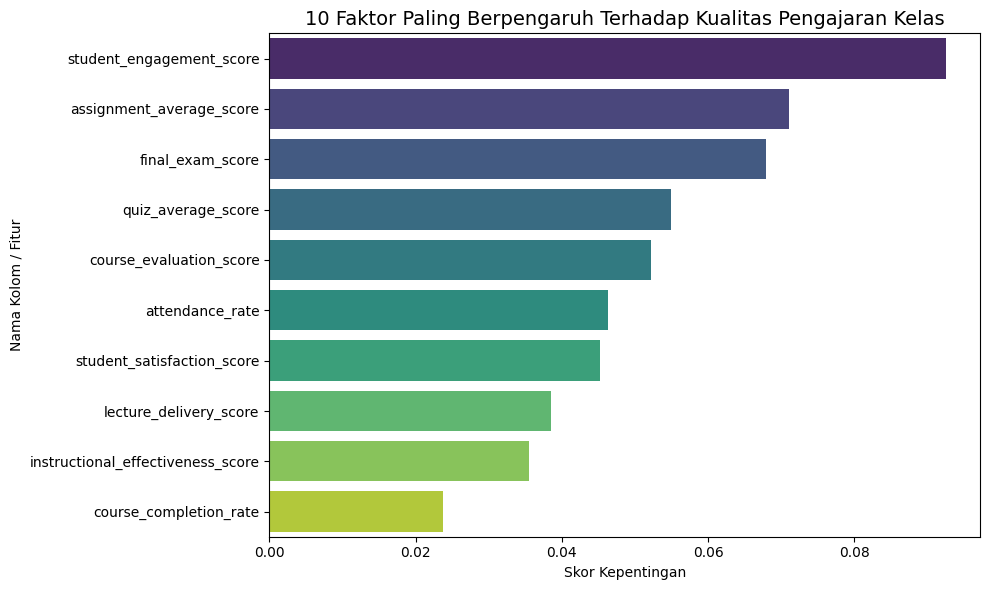

In [18]:
### MULAI CODE ###

# Dapatkan bobot/pengaruh dari setiap kolom fitur
importances = rf_model_balanced.feature_importances_
feature_names = X_train.columns

# Gabungkan ke dalam tabel lalu urutkan 10 yang paling besar
feature_imp_df = pd.DataFrame({'Fitur': feature_names, 'Tingkat Kepentingan': importances})
feature_imp_df = feature_imp_df.sort_values(by='Tingkat Kepentingan', ascending=False).head(10)

# Visualisasikan dengan grafik batang
plt.figure(figsize=(10, 6))
sns.barplot(x='Tingkat Kepentingan', y='Fitur', data=feature_imp_df, palette='viridis')
plt.title("10 Faktor Paling Berpengaruh Terhadap Kualitas Pengajaran Kelas", fontsize=14)
plt.xlabel("Skor Kepentingan")
plt.ylabel("Nama Kolom / Fitur")
plt.tight_layout()
plt.show()

### SELESAI CODE ###

# **5. Menyimpan Model**

In [19]:
### MULAI CODE ###

# Menyimpan model Random Forest yang sudah dilatih dengan SMOTE
joblib.dump(rf_model_smote, 'model_kualitas_pengajaran_rf.joblib')

# Menyimpan LabelEncoder (penting agar nanti bisa menerjemahkan angka 0,1,2,3 kembali ke teks)
joblib.dump(label_encoder, 'label_encoder_pengajaran.joblib')

print("Model dan Encoder berhasil disimpan!")

### SELESAI CODE ###

Model dan Encoder berhasil disimpan!


## **End of Code.**